In [1]:
import pandas as pd

df = pd.read_parquet('../data/raw/yellow_tripdata_2025-12.parquet')

In [2]:
df.shape

(4305006, 20)

In [3]:
df.sample(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
4293096,1,2025-12-31 20:12:19,2025-12-31 20:23:34,NaN,1.20,NaN,None,87,232,0,7.94,0.0,0.5,0.00,0.0,1.0,13.82,NaN,NaN,0.75
1275141,2,2025-12-11 21:50:36,2025-12-11 22:12:51,1.0,7.27,1.0,N,87,263,1,31.00,1.0,0.5,6.62,0.0,1.0,43.37,2.5,0.0,0.75
4006252,2,2025-12-20 22:23:36,2025-12-20 22:27:54,NaN,0.60,NaN,None,209,88,0,6.04,0.0,0.5,0.00,0.0,1.0,10.79,NaN,NaN,0.75


In [4]:
df.isna().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1195482
trip_distance                  0
RatecodeID               1195482
store_and_fwd_flag       1195482
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1195482
Airport_fee              1195482
cbd_congestion_fee             0
dtype: int64

In [5]:
# ЧАСТЬ 1: ПРОПУСКИ И ДУБЛИКАТЫ
# строки с хотя бы одним NaN — это ровно те же строки, где payment_type == 0

df.index[df.isna().any(axis=1)].equals(df.index[df["payment_type"] == 0])

True

In [6]:
df[df.duplicated()].shape

(0, 20)

In [7]:
# ЧАСТЬ 2: МИНИМАЛЬНАЯ ОЧИСТКА ДАННЫХ
mask_1 = df["tpep_pickup_datetime"] > df["tpep_dropoff_datetime"]
mask_2 = (df["tpep_pickup_datetime"] == df["tpep_dropoff_datetime"]) & (df['trip_distance'] != 0)
mask_3 = (df["tpep_pickup_datetime"] < '2025-12-01') | (df["tpep_pickup_datetime"] >= '2026-01-01')
df[mask_1 | mask_2 | mask_3]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
6,2,2025-11-30 23:59:23,2025-12-01 00:12:43,1.0,2.59,1.0,N,142,263,1,14.90,1.0,0.5,3.98,0.00,1.0,23.88,2.5,0.00,0.00
105,7,2025-12-01 00:08:50,2025-12-01 00:08:50,1.0,0.90,1.0,N,239,143,1,6.50,0.0,0.5,2.30,0.00,1.0,13.80,2.5,0.00,0.00
106,7,2025-12-01 00:35:17,2025-12-01 00:35:17,4.0,2.54,1.0,N,143,170,2,19.80,0.0,0.5,0.00,0.00,1.0,25.55,2.5,0.00,0.75
241,7,2025-12-01 00:57:33,2025-12-01 00:57:33,1.0,8.74,1.0,N,138,107,1,34.50,0.0,0.5,10.79,6.94,1.0,64.73,2.5,6.75,0.75
306,7,2025-12-01 00:10:13,2025-12-01 00:10:13,1.0,1.46,1.0,N,186,113,1,8.60,0.0,0.5,2.87,0.00,1.0,17.22,2.5,0.00,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4097497,6,2025-12-23 17:14:44,2025-12-23 16:30:00,NaN,4.16,NaN,None,71,76,0,2.90,0.0,0.5,0.00,0.00,0.3,0.00,NaN,NaN,0.00
4112597,2,2025-12-24 09:05:52,2025-12-24 09:05:52,NaN,0.96,NaN,None,141,141,0,10.06,0.0,0.5,0.00,0.00,1.0,14.81,NaN,NaN,0.75
4159523,2,2025-12-25 22:40:01,2025-12-25 22:40:01,NaN,2.42,NaN,None,197,197,0,16.20,0.0,0.5,0.00,0.00,1.0,17.70,NaN,NaN,0.00
4179285,2,2025-12-26 22:12:39,2025-12-26 22:12:39,NaN,5.74,NaN,None,197,197,0,32.08,0.0,0.5,0.00,0.00,1.0,33.58,NaN,NaN,0.00


In [8]:
# проблемных строк 60862
# 55975 записей составляют ~1.3% от размера всей выборки, удалим эти записи
df = df[~(mask_1 | mask_2 | mask_3)]

In [9]:
# проверяю PULocationID, DOLocationID
zones = pd.read_csv("../data/raw/taxi_zone_lookup.csv")
valid_ids = set(zones["LocationID"])
print('записей с несуществующими зонами посадки:', df[~(df["PULocationID"].isin(valid_ids))].shape[0])
print('записей с несуществующими зонами высадки:', df[~(df["DOLocationID"].isin(valid_ids))].shape[0])

записей с несуществующими зонами посадки: 0
записей с несуществующими зонами высадки: 0


In [10]:
df[df["PULocationID"] == 264]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
376,1,2025-12-01 00:12:57,2025-12-01 00:13:05,1.0,0.00,1.0,N,264,138,2,3.00,7.75,0.5,0.00,0.00,1.0,12.25,0.0,1.75,0.00
1022,2,2025-12-01 00:14:51,2025-12-01 00:32:16,2.0,8.30,1.0,N,264,236,1,33.80,1.00,0.5,9.30,6.94,1.0,55.79,2.5,0.00,0.75
1351,2,2025-12-01 00:54:03,2025-12-01 01:07:12,1.0,10.27,1.0,N,264,138,2,38.70,1.00,0.5,0.00,0.00,1.0,44.45,2.5,0.00,0.75
1582,2,2025-12-01 01:32:23,2025-12-01 02:03:38,1.0,18.74,2.0,N,264,264,1,70.00,0.00,0.5,5.00,6.94,1.0,85.94,2.5,0.00,0.00
2904,1,2025-12-01 04:48:35,2025-12-01 05:07:10,1.0,11.90,1.0,N,264,132,1,44.30,1.00,0.5,5.00,0.00,1.0,51.80,0.0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4278162,2,2025-12-31 12:04:22,2025-12-31 12:53:16,NaN,0.00,NaN,None,264,264,0,76.60,0.00,0.5,13.36,0.00,1.0,91.46,NaN,NaN,0.00
4279448,2,2025-12-31 13:52:37,2025-12-31 13:59:11,NaN,1.13,NaN,None,264,264,0,13.32,0.00,0.5,0.00,0.00,1.0,14.82,NaN,NaN,0.00
4289339,1,2025-12-31 19:42:10,2025-12-31 19:47:07,NaN,0.60,NaN,None,264,161,0,7.20,2.50,0.5,2.89,0.00,1.0,17.34,NaN,NaN,0.75
4291517,2,2025-12-31 19:46:26,2025-12-31 19:58:46,NaN,0.00,NaN,None,264,264,0,11.18,0.00,0.5,0.00,0.00,1.0,13.68,NaN,NaN,0.00


In [11]:
# записей с зоной 264 всего 5679
# Для анализа локального спроса нужна известная зона посадки, поэтому удаляю их.
df = df[df["PULocationID"] != 264]

In [12]:
# ЧАСТЬ 3: EDA
print('удалено записей из таблицы:', 4305006-df.shape[0])
print('осталось записей о поездке:', df.shape[0])
print('максимальная и минимальная даты в таблице:', df['tpep_pickup_datetime'].max(), df['tpep_pickup_datetime'].min())

удалено записей из таблицы: 61654
осталось записей о поездке: 4243352
максимальная и минимальная даты в таблице: 2025-12-31 23:59:59 2025-12-01 00:00:00


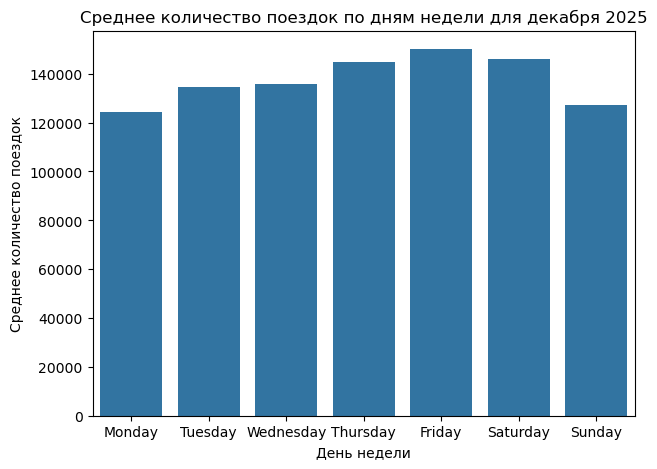

In [13]:
# рассмотрим распределение записей по дням недели (считая для начала поездки) и визуализируем
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))
first_group = df.groupby(df['tpep_pickup_datetime'].dt.date).size()
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
second_group = first_group.groupby(pd.to_datetime(first_group.index).day_name()).mean()
second_group = second_group.reindex(weekday_order)
sns.barplot(data=second_group).set(title='Среднее количество поездок по дням недели для декабря 2025',
                                   xlabel='День недели',
                                   ylabel='Среднее количество поездок');

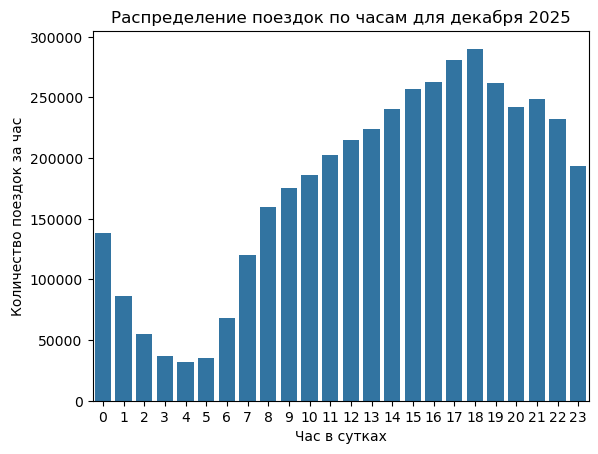

In [14]:
# рассмотрим распределение записей по часам и визуализируем
gr = df.groupby(df['tpep_pickup_datetime'].dt.hour).size()
sns.barplot(data=gr).set(
    title='Распределение поездок по часам для декабря 2025', 
    xlabel='Час в сутках', 
    ylabel='Количество поездок за час');

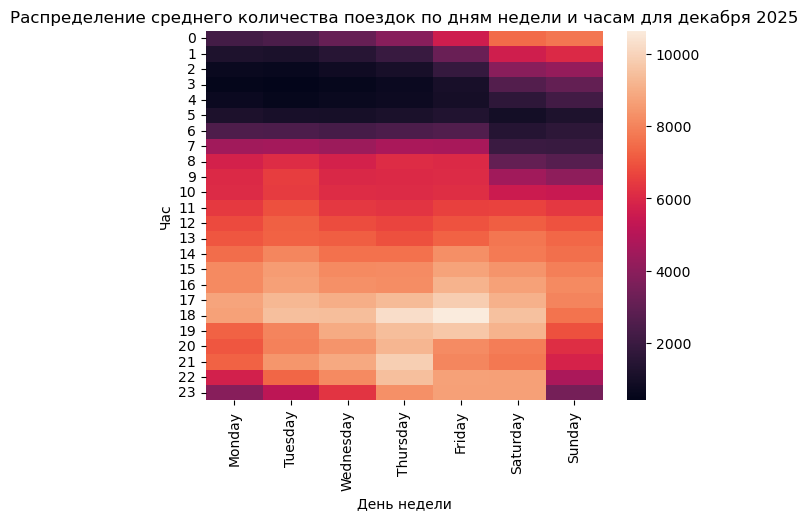

In [16]:
# Посмотрим среднее количество поездок по дню недели и часу
day_hour = df.groupby([
    df["tpep_pickup_datetime"].dt.date.rename("date"), 
    df["tpep_pickup_datetime"].dt.day_name().rename("day_of_week"), 
    df["tpep_pickup_datetime"].dt.hour.rename("hour")]).size().rename("trips")
day_hour = day_hour.reset_index()

day_hour = day_hour.groupby([
    day_hour["day_of_week"],
    day_hour["hour"]])["trips"].mean()
day_hour = day_hour.reset_index()


day_hour = day_hour.pivot(columns="day_of_week", index="hour", values="trips")
day_hour = day_hour[weekday_order]

sns.heatmap(day_hour).set(title="Распределение среднего количества поездок по дням недели и часам для декабря 2025", 
                          xlabel="День недели", 
                          ylabel="Час");

In [17]:
# Графики распределений не имеют значимых отличий от ноябрьских,
# пик активности тут приходится на пятницу 18 ч.

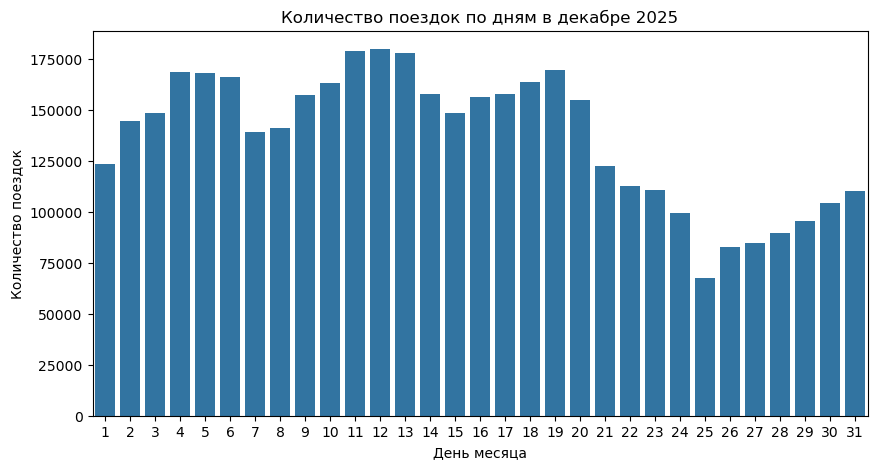

In [18]:
# Рассмотрим спрос на такси в конкретные даты

from datetime import date


gr_date = df.groupby(df["tpep_pickup_datetime"].dt.date.rename("date")).size().rename("trips")
gr_date = gr_date.to_frame()

gr_date = gr_date.reset_index()
gr_date["date"] = pd.to_datetime(gr_date["date"])
gr_date["date"] = gr_date["date"].dt.day

plt.figure(figsize=(10, 5))
sns.barplot(data=gr_date, x="date", y="trips").set(
    title="Количество поездок по дням в декабре 2025", 
    xlabel="День месяца", 
    ylabel="Количество поездок");

# Недельная цикличность сохраняется.
# Особенно низкие значения наблюдаются по понедельникам: 1, 8, 15, 22, 29 декабря.
# 25 декабря в США отмечают Рождество, празднования длятся несколько дней,
# это объясняет падение количества поездок в конце месяца.

In [19]:
# Зона посадки PULocationID

start_zone_borough = df.groupby(df["PULocationID"]).size().rename("trips")
start_zone_borough = start_zone_borough.to_frame()
start_zone_borough = start_zone_borough.merge(zones[["LocationID", "Borough", "Zone"]], left_index=True, right_on='LocationID')
start_zone_borough = start_zone_borough.set_index("LocationID")
start_borough = start_zone_borough.groupby(start_zone_borough["Borough"])["trips"].sum().sort_values()
start_borough = start_borough.to_frame()
start_borough
# ожидаемо, поездки на жёлтых такси всё так же преобладают на Манхэттене

,trips
Borough,
Staten Island,462
EWR,711
Bronx,39175
Brooklyn,160284
Queens,386462
Manhattan,3654338


In [20]:
# ЧАСТЬ 4: ИСКОМЫЕ ДАННЫЕ
venue_zone_ids = [79, 161, 163, 186, 239]

df_selected = df[
    df["PULocationID"].isin(venue_zone_ids)
]

data_pickup = (
    df_selected
    .groupby([
        df_selected["tpep_pickup_datetime"].dt.floor("D").rename("date"),
        df_selected["tpep_pickup_datetime"].dt.hour.rename("hour"),
        df_selected["PULocationID"].rename("LocationID")
    ])
    .size()
    .rename("pickups")
    .reset_index()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-12-01,0,79,51
1,2025-12-01,0,161,22
2,2025-12-01,0,163,13
3,2025-12-01,0,186,156
4,2025-12-01,0,239,53
...,...,...,...,...
3715,2025-12-31,23,79,226
3716,2025-12-31,23,161,119
3717,2025-12-31,23,163,60
3718,2025-12-31,23,186,75


In [21]:
# В таблице должно быть 31 день x 24 часа x 5 зон = 3720 записей, это именно так.

In [22]:
# ЧАСТЬ 5: СОХРАНЕНИЕ ОБРАБОТАННЫХ ДАННЫХ

from pathlib import Path

processed_taxi_dir = Path("../data/processed/taxi")
processed_taxi_dir.mkdir(parents=True, exist_ok=True)

output_path = (
    processed_taxi_dir
    / "yellow_taxi_pickups_2025_12.parquet"
)

data_pickup.to_parquet(
    output_path,
    index=False
)

In [23]:
data_pickup_check = pd.read_parquet(output_path)

print("Размер:", data_pickup_check.shape)
print(
    "Дубликаты:",
    data_pickup_check.duplicated(
        subset=["date", "hour", "LocationID"]
    ).sum()
)
print("Пропуски:", data_pickup_check.isna().sum().sum())
print("Количество зон:", data_pickup_check["LocationID"].nunique())

assert data_pickup_check.equals(data_pickup)

Размер: (3720, 4)
Дубликаты: 0
Пропуски: 0
Количество зон: 5
